# Normalize Total Gradient (NTG) for Aerial Image Registration
## Aberrations Complete [Translation & Zoom x30] (v1)

### LIBRERIAS PARA LA IMPLEMENTACIÓN

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from scipy.optimize import minimize_scalar

### CARGA DE IMAGENES [RGB & NIR]

In [2]:
ti = 1 # Definimos el total de imagenes a trabajar [de 1 a 185 tomando al dataset como base]

## ---- Inicialización de listas para almacenar las imagenes RGB y NIR ---- ##

img_BGR = []                # Lista de imagenes BGR (formato base)
img_NIR = []                 # Lista de imagenes NIR (espectro Infrarrojo cercano)
img_RGB = []                # Lista de imagenes RGB (conversión para visualización de color apropiada)
img_RGBgray = []            # Lista de imagenes RGB en grayscale (usado para aplicar operaciones de Image Registration)

## ---- Carga de imagenes del dataset y operaciones sobre ellas (aberraciones,conversiones,etc.) ---- ## {n:03d}
for n in range(1):
    bgr = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Sat_images/Photos_2018/GC_019.png')
    ir = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Additional_data/Infrared_images/Infrared_2018/GC_019_Infrarred.png',cv2.IMREAD_GRAYSCALE)

    # Verificación de carga de imagenes para informar de errores
    if bgr is None or ir is None:
        print(f'Error al cargar la imagen {n}')
        continue

    ## ---- Conversiones de formato ---- ##
    rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)          # Conversión de BGR a RGB
    rgb_gray = cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)    # Conversión de RGB a Grayscale

    ## ---- Guardar la imagenes en sus respectivas listas ---- ##
    img_BGR.append(bgr)                            # Agregar las imagenes BGR a la lista
    img_RGB.append(rgb)                            # Agregar las imagenes RGB a la lista
    img_NIR.append(ir)                              # Agregar las imagenes NIR a la lista
    img_RGBgray.append(rgb_gray)                   # Agregar las imagenes RGB en grayscale a la lista


### GENERACIÓN DE ABERRACIONES [TRASLACIÓN EN NIR | ZOOM EN RGB] 

#### ABERRACIÓN - Traslación

In [3]:
def traslation_img (img,trans_x,trans_y):
    
    h_img, w_img = img.shape[:2]                                 # Obtenemos las dimensiones de la imagen

    tras_x = trans_x                                             # Pixeles de desplazamiento en x (+ derecha, - izquierda)
    tras_y = trans_y                                             # Pixeles de desplazamiento en y (+ abajo, - arriba)
    
    m_translation = np.float32([[1,0,tras_x],[0,1,tras_y]])      # Matriz de traslación 

    translation_img = cv2.warpAffine(img,m_translation,(w_img,h_img)) # Generamos la imagen con traslación

    return translation_img

In [4]:
img_NIR_translation = [] 

tras_x = +500
tras_y = +500

for n in range(len(img_RGB)):

    img_NIR_trans = traslation_img(img_NIR[n],tras_x,tras_y)
    img_NIR_translation.append(img_NIR_trans)

#### ABERRACIÓN - Zoom

In [5]:
def zoom_cv(img,zoom_factor):
    
    h, w = img.shape[:2]

    if zoom_factor <= 0 or zoom_factor <= 1:
        return img

    new_w = int(w/zoom_factor)
    new_h = int(h/zoom_factor)

    x1 = int((w - new_w) / 2)
    y1 = int((h - new_h) / 2)
    x2 = x1 + new_w
    y2 = y1 + new_h

    crop_zoom = img[y1:y2, x1:x2]

    img_zoom = cv2.resize(crop_zoom,(w,h),interpolation=cv2.INTER_CUBIC)

    return img_zoom 

In [6]:
zoom_imgGRAY_list = []
zoom_img_list = []

zoom_factor = 10.00

for n in range(len(img_RGB)):

    zoom_img = zoom_cv(img_RGB[n],zoom_factor)
    gray_zoom = cv2.cvtColor(zoom_img.copy(),cv2.COLOR_RGB2GRAY)

    zoom_imgGRAY_list.append(gray_zoom)
    zoom_img_list.append(zoom_img)

### VISUALIZACIÓN [RGB, IR & ABERRACIONES]

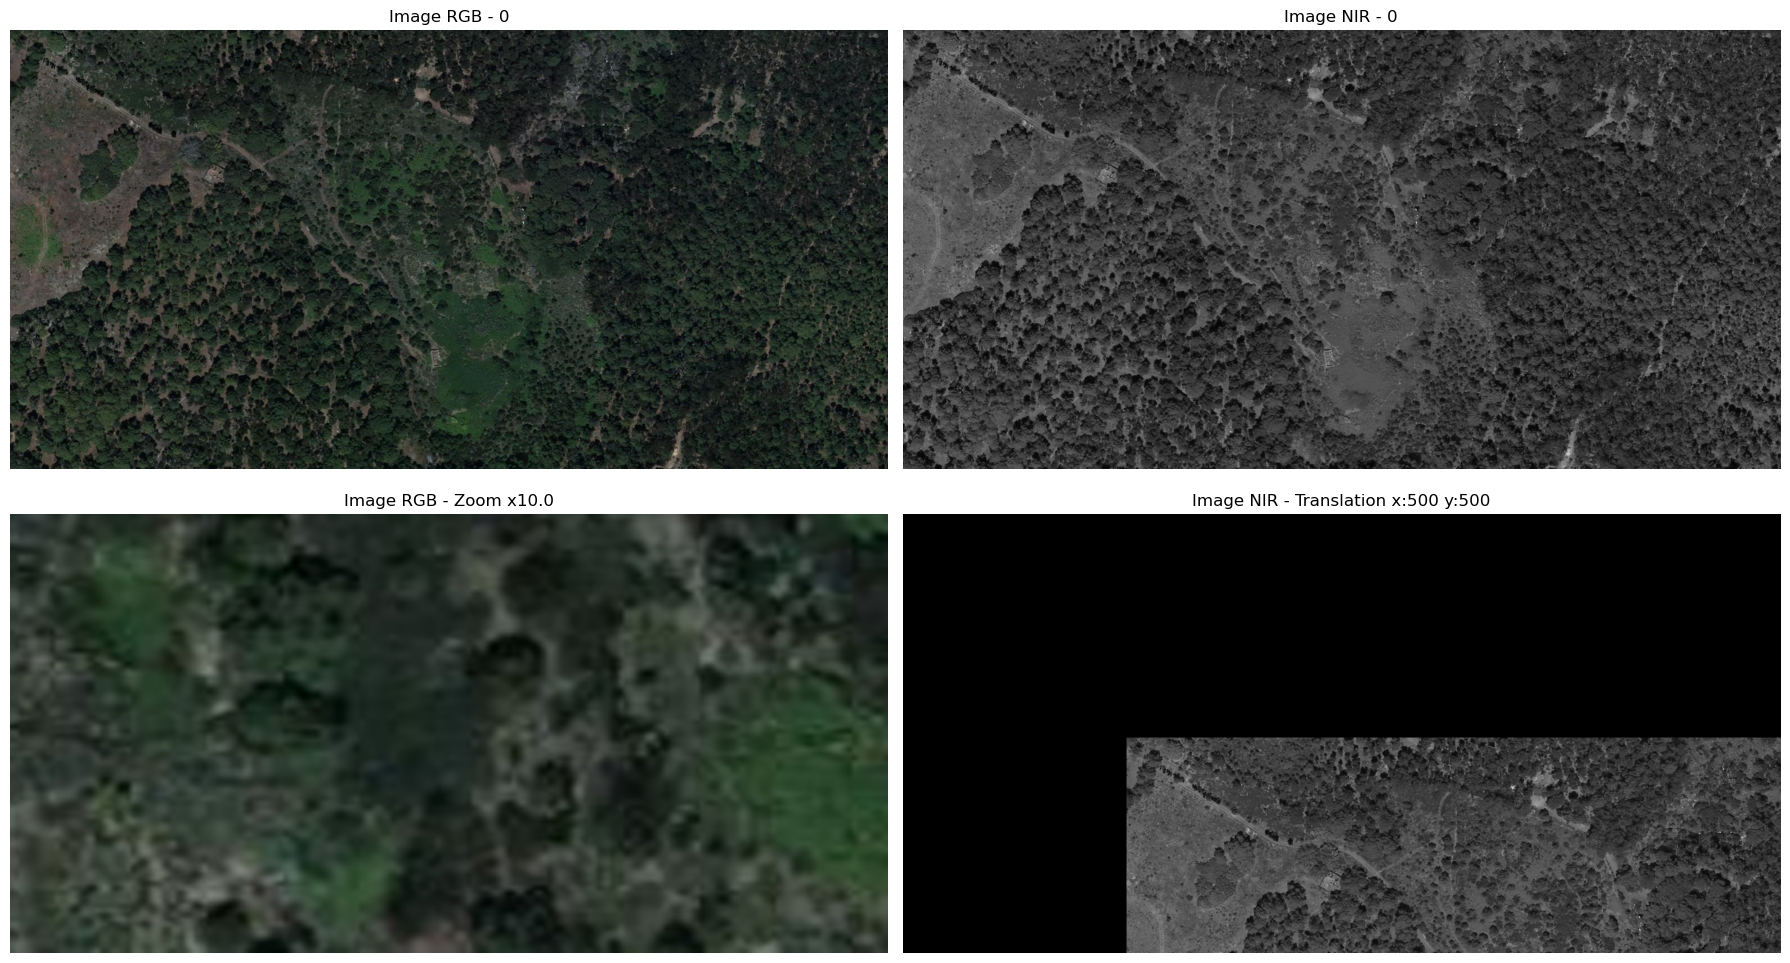

In [7]:
for n in range(len(img_RGB)):
    
    plt.figure(figsize=(18,10))

    plt.subplot(2,2,1)
    plt.title(f"Image RGB - {n}")
    plt.imshow(img_RGB[n])
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.title(f"Image NIR - {n}")
    plt.imshow(img_NIR[n],cmap='gray')
    plt.axis('off')

    plt.subplot(2,2,3)
    plt.title(f"Image RGB - Zoom x{zoom_factor}")
    plt.imshow(zoom_img_list[n])
    plt.axis('off')
    
    plt.subplot(2,2,4)
    plt.title(f"Image NIR - Translation x:{tras_x} y:{tras_y}")
    plt.imshow(img_NIR_translation[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### NTG for AERIAL IMAGE REGISTRATION (function v1)

In [8]:
def aerial_image_reg_NTG_v2(img_RGB,img_NIR,

                            # -- Tamaño de la piramide -- #
                            levels,
                            
                            # -- Factor de escala -- #
                            scale_factor,

                            # -- Global scale scan -- #
                            scale_bounds,
                            scale_samples,
                            consistency_tol,

                            # -- Local DE -- #
                            local_population,
                            local_generations,

                            # -- Local search region -- #
                            delta_translation,
                            seed,

                            # -- Global Translation -- #
                            global_population,
                            global_generations,
                            
                            global_translation_ratio,
                            
                            global_scale_rel,
                            global_shear_rel,

                            # -- Overlap -- #
                            min_overlap_global,
                            
                            translation_overlap_floor,
                            translation_overlap_soft,
                            translation_overlap_penalty,
                            
                            min_overlap_local
                           ):

    #### ============================================================================= ####
    ##                     FUNCIONES PARA IMAGE REGITRATION POR NTG                      ##
    #### ============================================================================= ####

    #### ======================== NORMALIZACIÓN ======================== ####
    
    ## ------ Función de Normalización para Normalize Total Gradient ------ ##
    def normalize_image(img):
        
        img = img.astype(np.float32)      # Conversión del tipo de dato a float de 32 bits

        min_val = np.min(img)             # Valores mínimos de la imagen normalizada
        max_val = np.max(img)             # Valores máximos de la imagen normalizada

        if max_val - min_val < 1e-8:      # Control para evitar divisiones entre 0 y con ello errores
            return np.zeros_like(img)

        norm_img = (img - min_val)/(max_val - min_val)  # Normalizamos la intensidad de la imagen
    
        return norm_img

    #### ======================== CÁLCULO DE GRADIENTES ======================== ####
    
    ## ------ Función para calcular Derivadas Espaciales para Gradientes ------##
    def spatial_derivative(img,dx,dy,ksize=3):
        
        kx, ky = cv2.getDerivKernels(dx,dy,ksize,normalize=True,ktype=cv2.CV_32F)
        derivative = cv2.sepFilter2D(img.astype(np.float32),cv2.CV_32F,kx,ky,borderType=cv2.BORDER_REFLECT101)

        return derivative

    ## ------ Función para el cálculo del Gradiente en X y Y ------ ##
    def compute_gradients(img):
        
        fx = spatial_derivative(img,dx=1,dy=0,ksize=3)  # Gradiente X
        fy = spatial_derivative(img,dx=0,dy=1,ksize=3)  # Gradiente Y

        return fx, fy

    #### ========== CÁLCULO DE TRANSFORMACIONES AFÍN, WARP Y OVERLAP ========== ####

    ## ------ Función para obtener la matriz afin [u(x,y,p) y v(x,y,p)] ------ ##
    def affine_matrix(img,identity_params):
        
        ## -- Parámetros referentes a la forma de la imagen -- ##
        H, W = img.shape[:2]                          # Alto y ancho de la imagen

        ## -- Matrices de coordenadas bidimensionales -- ##
        y, x = np.indices((H, W), dtype=np.float32)   # Matrices de coordenadas verticales (y) y horizontales (x)

        ## -- Parámetros para la M. Afín -- ##
        p1, p2, p3, p4, p5, p6 = identity_params      # Afinidad dada por: escala X, escala Y, shear, rotación y traslación

        ## -- Generar el Modelo Afín [Basado en el paper NTG] -- ##
        u = (p1*x + p2*y + p3).astype(np.float32)     # Mapea la coordenada horizontal x
        v = (p4*x + p5*y + p6).astype(np.float32)     # Mapea la coordenada horizontal y
 
        return u, v

    ## ------ Función para realizar el Warp Affine con REMAP para NIR ------ ##
    def warp_image_ntg(img,identity_params):
        
        ## --- Cálcular las coordenadas afines --- ##
        u, v = affine_matrix(img,identity_params)

        ## --- Convertir a float32 para manejar los datos --- ##
        u = u.astype(np.float32)
        v = v.astype(np.float32)

        ## --- Ejecutamos el WarpAffine con REMAP [basado en el paper] con los parámetros dados --- ##
        warped = cv2.remap(
            img,
            u,
            v,
            interpolation=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )

        return warped

    ## ------ Función para generar el traslape en NIR (puntos con coordenadas válidas) ------ ##
    def warp_mask(img,identity_params):
        
        ## --- Obtenemos las dimensiones de la imagen --- ##
        H, W = img.shape[:2]

        ## --- Obtenemos las coordenadas afines para el overlaping --- ##
        u, v = affine_matrix(img,identity_params)

        ## --- Obtenemos la región de overlap --- ##
        warped_mask = (
            (u >= 0) &
            (u < W - 1) &
            (v >= 0) &
            (v < H - 1)
        )

        return warped_mask

    #### ======================== CONSTRUCCIÓN DE PIRÁMIDES MULTIRESOLUCIÓN ======================== ####

    ## ------ Función para construir pirámides multiresolución para NTG ------ ##
    def build_pyramid(img,levels,scale):
        
        pyramid = [img]            # Lista que almacena las diferentes resoluciones de la imagen de referencia
        current_lv = img           # Imagen[resolución] actual de trabajo

        for _ in range(levels - 1):
            
            ## --- Calcular nuevas dimensiones --- ##
            new_width = current_lv.shape[1] // scale     # Dimensiones para el ancho de la imagen
            new_height = current_lv.shape[0] // scale    # Dimensiones para el largo de la imagen

            ## --- Redimensionamos la imagen  --- ##
            current_lv = cv2.resize(
                current_lv,
                (new_width, new_height),
                interpolation=cv2.INTER_AREA
            )

            pyramid.append(current_lv)

        return pyramid

    ## ------ Función para ajustar el orden de la pirámide SMALL-to-LARGE ------ ##
    def build_NTG_pyramid(img,levels,scale):
        
        ## --- Construimos la pirámide base para el modelo --- ##
        pyramid_NTG = build_pyramid(
            img,
            levels,
            scale
        )

        ## --- Invertimos el orden de la pirámide del MÁS PEQUEÑO al MÁS GRANDE --- ##
        pyramid_NTG.reverse()

        return pyramid_NTG

    #### ======================== CÁLCULO NORMALIZED TOTAL GRADIENT ======================== ####

    ## ------ Función para realizar Image Registration por NTG ------ ##
    def compute_ntg(img_reference,reference_gx,reference_gy,img_floating,identity_params,min_overlap=0.25):
        
        ## --- Warp de la imagen NIR para ajustarla a la RGB [paper] --- ##
        warped = warp_image_ntg(img_floating,identity_params)

        ## --- Máscara de traslape válido --- ##
        mask = warp_mask(img_floating,identity_params)

        overlap_pixels = np.sum(mask)
        overlap_ratio = (overlap_pixels/mask.size)

        ## --- Evitar soluciones invalidas (No se ajustan) --- ##
        if overlap_ratio < min_overlap:
            return 1.0

        ## --- Gradientes de la imagen warped NIR --- ##
        warped_gx, warped_gy = compute_gradients(warped)

        ## --- Diferencia entre los gradientes del RGB y NIR warped --- ##
        diff_gx = warped_gx - reference_gx     # Gradiente en X
        diff_gy = warped_gy - reference_gy     # Gradiente en Y

        ## --- Cálculo del Numerador NTG --- ##
        numerator = (np.sum(np.abs(diff_gx[mask])) + np.sum(np.abs(diff_gy[mask])))

        ## --- Cálculo del Denominador NTG --- ##
        denominator = (np.sum(np.abs(warped_gx[mask])) + np.sum(np.abs(warped_gy[mask])) +
                       np.sum(np.abs(reference_gx[mask])) + np.sum(np.abs(reference_gy[mask])))
    
        if denominator < 1e-8:                # Caso para evitar la división entre 0
            return 1.0

        ## --- Cálculo final del NTG del modelo afín --- ##
        ntg = float(numerator / denominator)

        return ntg

    #### ========================= CÁLCULO DEL OVERLAP EXISTENTE ========================= ####

    def compute_overlap_ratio(img_floating,identity_params):

        mask = warp_mask(img_floating,identity_params)
        overlap_ratio = (np.sum(mask)/mask.size)

        return float(overlap_ratio)

    #### ========================= ADAPTATIVE TRANSLATION OVERLAP ========================= ####
    
    def translation_overlap_penalty_function(overlap_ratio,
                                             overlap_floor=0.05,
                                             overlap_soft=0.50,
                                             penalty_strength=0.02):

        # --- Región físicamente inválida --- #
        if overlap_ratio < overlap_floor:
            return np.inf

        # --- Overlap suficientemente grande --- #
        if overlap_ratio >= overlap_soft:
            return 0.0
        
        # --- Déficit normalizado entre soft y floor --- #
        denominator = max(overlap_soft - overlap_floor, 1e-8)

        deficit = (overlap_soft - overlap_ratio) / denominator

        deficit = np.clip(deficit, 0.0, 1.0)

        # --- Penalización cuadrática suave --- #
        penalty = penalty_strength * (deficit ** 2)

        return float(penalty)

    ## ------ Evaluación NTG especial para Translation Search ------ ##
    def evaluate_translation_candidate(img_reference,reference_gx,reference_gy,img_floating,
                                       identity_params,overlap_floor=0.05,overlap_soft=0.50,
                                       penalty_strength=0.02):

        # --- Warp de NIR --- #
        warped = warp_image_ntg(img_floating,identity_params)

        # --- Máscara real de overlap --- #
        mask = warp_mask(img_floating,identity_params)

        overlap_pixels = int(np.sum(mask))
        overlap_ratio = float(overlap_pixels/mask.size)

        if overlap_ratio < overlap_floor:

            return (np.inf, np.inf, overlap_ratio, np.inf)

        # --- Gradientes NIR warped --- #
        warped_gx, warped_gy = compute_gradients(warped)

        # --- Diferencias de gradientes RGB-NIR --- #
        diff_gx = warped_gx - reference_gx
        diff_gy = warped_gy - reference_gy

        # --- Numerador NTG --- #
        numerator = (np.sum(np.abs(diff_gx[mask]))+
                     np.sum(np.abs(diff_gy[mask])))

        # --- Denominador NTG --- #
        denominator = (np.sum(np.abs(warped_gx[mask])) + 
                       np.sum(np.abs(warped_gy[mask])) +
                       np.sum(np.abs(reference_gx[mask])) +
                       np.sum(np.abs(reference_gy[mask]))
                      )

        if denominator < 1e-8:

            return (np.inf, np.inf, overlap_ratio, np.inf)

        # --- NTG Puro --- #
        ntg = float(numerator / denominator)

        # --- Penalización adaptative --- #
        penalty = translation_overlap_penalty_function(overlap_ratio,overlap_floor=overlap_floor,
                                                       overlap_soft=overlap_soft,
                                                       penalty_strength=penalty_strength)

        score = ntg + penalty

        return (float(score),ntg,overlap_ratio,penalty)

    #### ======================== CÁLCULO DIFFERENTIAL EVOLUTION ======================== ####

    ## ------ Función para ejecutar Differential Evolution por capa / nivel ------ ##

    def diffEVO_for_NTG(img_reference,img_floating,bounds,population=30,generations=200,seed=42,min_overlap=0.25):
        
        ref_gx, ref_gy = compute_gradients(img_reference)

        def objetive(identity_params):

            ntg = compute_ntg(img_reference,ref_gx,ref_gy,img_floating,identity_params,min_overlap=min_overlap)

            return ntg

        result = differential_evolution(objetive,
                                        bounds=bounds,
                                        popsize=population,
                                        maxiter=generations,
                                        polish=False,
                                        seed=seed,
                                        workers=1,
                                        updating="immediate",
                                        disp=False  #True
                                       )
        return result

    #### ================ IMPLEMENTACIONES DINÁMICAS PARA COARSE-TO-FINE ================ ####

    ## ================== ZOOM SEARCH ================== ##
    ## ------ Función para cálcular Local Bounds para NTG ------ ##
    def local_bounds_adaptative(identity_params,scale_rel=0.10,
                                shear_rel=0.05,delta_translation=2.0):
        
        p = np.asarray(identity_params,dtype=np.float64)

        sx = abs(p[0])
        sy = abs(p[4])

        dsx = max(1e-4,scale_rel*sx)
        dsy = max(1e-4,scale_rel*sy)

        shear_limit = max(1e-5,shear_rel*min(sx,sy))

        bounds = [
            
            # BOUNDS - p1
            (p[0] - dsx, p[0] + dsx),

            # BOUNDS - p2
            (p[1] - shear_limit, p[1] + shear_limit),

            # BOUNDS - P3 [Translation X]
            (p[2] - delta_translation, p[2] + delta_translation),

            # BOUNDS - p4
            (p[3] - shear_limit, p[3] + shear_limit),

            # BOUNDS - p5
            (p[4] - dsy, p[4] + dsy),

            # BOUNDS - P6 [Translation Y]
            (p[5] - delta_translation, p[5] + delta_translation)
        ]

        return bounds

    ## ------ Función para encontrar la escala global a trabajar para NTG ------ ##
    def global_scale_scan_log(img_reference,img_floating,
                              scale_bounds=(0.005,1.05),
                              num_samples=400,min_overlap=0.25):
        
        scales = np.geomspace(scale_bounds[0],
                              scale_bounds[1],
                              num_samples)

        ref_gx, ref_gy = compute_gradients(img_reference)

        H, W = img_reference.shape[:2]

        cx = (W - 1) / 2.0
        cy = (H - 1) / 2.0

        ntg_values = []

        for s in scales:
            
            p = np.array([s, 0.0, cx*(1.0 - s),
                          0.0, s, cy*(1.0 - s)],
                          dtype=np.float64)

            value = compute_ntg(img_reference,ref_gx,ref_gy,img_floating,p,min_overlap=min_overlap)

            ntg_values.append(value)
            
        ntg_values = np.asarray(ntg_values)

        idx = np.argmin(ntg_values)

        return (scales[idx], ntg_values[idx], scales, ntg_values)

    ## ------ Función para encontrar el nivel adecuado de trabajo de la pirámide NTG ------ ##
    def find_reliable_global_level(reference_pyramid,floating_pyramid,
                                   scale_bounds=(0.005, 1.05),
                                   scale_samples=300,
                                   consistency_tol=0.02,
                                   min_overlap=0.25):
        
        results = []

        for level in range(len(reference_pyramid) - 1):
            
            s_scan, ntg_scan, _, _ = global_scale_scan_log(reference_pyramid[level],floating_pyramid[level],
                                                           scale_bounds=scale_bounds,num_samples=scale_samples,
                                                           min_overlap=min_overlap)

            results.append({
                "level": level,
                "scale": s_scan,
                "ntg": ntg_scan
            })

            print(f"Level {level}: ",
                  f"Scale = {s_scan:.6f}",
                  f"NTG = {ntg_scan:.6f}")

        ## ---- Buscar entre dos niveles consecutivos consistentes ---- ##

        for i in range(len(results) - 1):
            
            s_a = results[i]["scale"]
            s_b = results[i + 1]["scale"]

            relative_difference = (abs(s_a - s_b)/max(abs(s_b), 1e-8))

            if relative_difference <= consistency_tol:
                
                # --- Elegimos el nivel más bajo de los dos --- #
                return (results[i]["level"],results)

        # --- Si ninguno coincide, usar el nivel más alto evaluado --- #
        return (results[-1]["level"],results)

    ## ------ Función para mejorar la escala para NTG ------ ##
    def refine_centered_scale_scalar(img_reference,img_floating,s_initial, 
                                     delta_s=0.01,global_bounds=(0.005, 1.05),
                                     min_overlap=0.25):
        
        ref_gx, ref_gy = compute_gradients(img_reference)

        H, W = img_reference.shape[:2]

        cx = (W - 1) / 2.0
        cy = (H - 1) / 2.0

        def objective(s):
            
            p = np.array([s, 0.0, cx*(1.0 - s),
                          0.0, s, cy*(1.0 - s)],
                          dtype=np.float64)

            return compute_ntg(img_reference,ref_gx,ref_gy,img_floating,p,min_overlap=min_overlap)

        lower = max(global_bounds[0],s_initial - delta_s)
        upper = min(global_bounds[1],s_initial + delta_s)

        result = minimize_scalar(objective,bounds=(lower,upper),
                                 method="bounded",options={"xatol":1e-6})

        s_refined = float(result.x)

        p_refined = np.array([s_refined, 0.0, cx*(1.0 - s_refined),
                              0.0, s_refined, cy*(1.0 - s_refined)],
                              dtype=np.float64)

        return p_refined, result

    ## ================== TRANSLATION SEARCH ================== ##
    ## ------ Función para encontrar la traslación global ------ ##
    def global_translation_bounds(img_reference,identity_params,translation_ratio=0.90):

        p = np.asarray(identity_params,dtype=np.float64).copy()

        H, W = img_reference.shape[:2]

        max_tx = translation_ratio * W
        max_ty = translation_ratio * H

        bounds = [
            (p[2] - max_tx, p[2] + max_tx),
            (p[5] - max_ty, p[5] + max_ty)
        ]

        return bounds

    ## ------ Barrido global discreto de traslación ------ ##
    def global_translation_scan(img_reference,img_floating,identity_params,translation_ratio=0.90,
                                coarse_step=4.0,refine_steps=(2.0,1.0),refine_radius=6.0,
                                overlap_floor=0.05,overlap_soft=0.50,penalty_strength=0.02):

        p_base = np.asarray(identity_params,dtype=np.float64).copy()

        ref_gx, ref_gy = compute_gradients(img_reference)

        bounds = global_translation_bounds(img_reference,p_base,translation_ratio=translation_ratio)

        tx_min, tx_max = bounds[0]
        ty_min, ty_max = bounds[1]

        def evaluate_translation(tx,ty):

            p = p_base.copy()

            p[2] = tx
            p[5] = ty

            score, ntg, overlap, penalty = evaluate_translation_candidate(img_reference,ref_gx,ref_gy,img_floating,p,
                                                                          overlap_floor=overlap_floor,
                                                                          overlap_soft=overlap_soft,
                                                                          penalty_strength=penalty_strength)

            return score, ntg, overlap, penalty

        best_score = np.inf
        best_ntg = np.inf
        
        best_tx = p_base[2]
        best_ty = p_base[5]

        best_overlap = 0.0
        best_penalty = np.inf

        tx_values = np.arange(tx_min, tx_max+coarse_step, coarse_step)
        ty_values = np.arange(ty_min, ty_max+coarse_step, coarse_step)

        for ty in ty_values:

            for tx in tx_values:

                score, ntg, overlap, penalty = evaluate_translation(tx,ty)

                if score < best_score:
                    
                    best_score = score
                    best_ntg = ntg
                    
                    best_tx = tx
                    best_ty = ty

                    best_overlap = overlap
                    best_penalty = penalty

        print("\n--- GLOBAL TRANSLATION SCAN ---")
        print(f"Coarse solution: tx={best_tx:.3f}, ty={best_ty:.3f}")
        print(f"Coarse NTG: {best_ntg:.8f}")

        print(f"Coarse NTG: {best_ntg:.8f}")
        print(f"Coarse overlap: {best_overlap:.6f}")
        print(f"Overlap penalty: {best_penalty:.8f}")
        print(f"Translation score: {best_score:.8f}")

        current_radius = refine_radius

        for step in refine_steps:

            local_tx_min = max(tx_min, best_tx - current_radius)
            local_tx_max = min(tx_max, best_tx + current_radius)

            local_ty_min = max(ty_min, best_ty - current_radius)
            local_ty_max = min(ty_max, best_ty + current_radius)

            tx_values = np.arange(local_tx_min, local_tx_max + step, step)
            ty_values = np.arange(local_ty_min, local_ty_max + step, step)

            stage_best_score = best_score
            stage_best_ntg = best_ntg
            
            stage_best_tx = best_tx
            stage_best_ty = best_ty

            stage_best_overlap = best_overlap
            stage_best_penalty = best_penalty

            for ty in ty_values:

                for tx in tx_values:

                    score, ntg, overlap, penalty = evaluate_translation(tx,ty)

                    if score < stage_best_score:

                        stage_best_score = score
                        stage_best_ntg = ntg
                        
                        stage_best_tx = tx
                        stage_best_ty = ty

                        stage_best_overlap = overlap
                        stage_best_penalty = penalty

            best_score = stage_best_score
            best_ntg = stage_best_ntg
            
            best_tx = stage_best_tx
            best_ty = stage_best_ty

            best_overlap = stage_best_overlap
            best_penalty = stage_best_penalty

            print(f"Refinement step={step:.2f}")
            
            print(f"tx={best_tx:.3f}")
            print(f"ty={best_ty:.3f}")
            
            print(f"NTG={best_ntg:.8f}")
            print(f"Overlap={best_overlap:.6f}")
            print(f"Penalty={best_penalty:.8f}")
            print(f"Score={best_score:.8f}")

            current_radius = max(2.0*step, step)

        p_result = p_base.copy()

        p_result[2] = best_tx
        p_result[5] = best_ty

        diagnostics = {
            "score": best_score,
            "ntg": best_ntg,

            "overlap": best_overlap,
            "penalty": best_penalty,

            "tx": best_tx,
            "ty": best_ty
        }

        return p_result, diagnostics

    ## ------ Refinamiento continuo de la traslación encontrada ------ ##
    def global_translation_refinement(img_reference,img_floating,identity_params,refinement_radius=2.5,
                                      population=15,generations=40,seed=42,overlap_floor=0.05,
                                      overlap_soft=0.50,penalty_strength=0.02):

        p_base = np.asarray(identity_params,dtype=np.float64).copy()

        ref_gx, ref_gy = compute_gradients(img_reference)

        H, W = img_reference.shape[:2]

        bounds = [
            (p_base[2] - refinement_radius, p_base[2] + refinement_radius),
            (p_base[5] - refinement_radius, p_base[5] + refinement_radius)
        ]

        def objective(t):

            tx, ty = t
            p = p_base.copy()

            p[2] = tx
            p[5] = ty

            score, _, _, _ = evaluate_translation_candidate(img_reference,ref_gx,ref_gy,img_floating,p,
                                                            overlap_floor=overlap_floor,overlap_soft=overlap_soft,
                                                            penalty_strength=penalty_strength)
            return score

        result = differential_evolution(objective,bounds=bounds,popsize=population,maxiter=generations,
                                        polish=True,seed=seed,workers=1,updating="immediate",disp=False)

        p_result = p_base.copy()

        p_result[2] = result.x[0]
        p_result[5] = result.x[1]

        score, ntg, overlap, penalty = evaluate_translation_candidate(img_reference,ref_gx,ref_gy,img_floating,p_result,
                                                                      overlap_floor=overlap_floor,overlap_soft=overlap_soft,
                                                                      penalty_strength=penalty_strength)

        diagnostics = {
            
            "score": score,
            "ntg": ntg,

            "overlap": overlap,
            "penalty": penalty,

            "tx": p_result[2],
            "ty": p_result[5],

            "de_result": result
        }

    
        return p_result, diagnostics

        
    ## ------ Función para hacer una busqueda de traslación ------ ##
    def global_translation_search(img_reference,img_floating,identity_params,
                                  
                                  translation_ratio=0.90,

                                  scan_coarse_step=4.0,
                                  scan_refine_steps=(2.0,1.0),
                                  scan_refine_radius=6.0,

                                  de_refinement_radius=2.5,
                                  
                                  population=15,
                                  generations=60,
                                  
                                  seed=42,
                                  
                                  overlap_floor=0.05,
                                  overlap_soft=0.50,
                                  penalty_strength=0.02):

        p_scan, scan_diagnostics = global_translation_scan(img_reference,img_floating,identity_params,
                                                           translation_ratio=translation_ratio,coarse_step=scan_coarse_step,
                                                           refine_steps=scan_refine_steps,refine_radius=scan_refine_radius,
                                                           overlap_floor=overlap_floor,overlap_soft=overlap_soft,
                                                           penalty_strength=penalty_strength)

        print(f"Translation before DE refinement: {p_scan}")
        print(f"Scan overlap: {scan_diagnostics['overlap']:.6f}")
        print(f"Scan NTG: {scan_diagnostics['ntg']:.8f}")
        print(f"Scan score: {scan_diagnostics['score']:.8f}")

        p_refined, refinement_diagnostics = global_translation_refinement(img_reference,img_floating,p_scan,refinement_radius=de_refinement_radius,
                                                                          population=population,generations=generations,seed=seed,
                                                                          overlap_floor=overlap_floor,overlap_soft=overlap_soft,
                                                                          penalty_strength=penalty_strength)

        print(f"Translation after DE refinement: {p_refined}")
        print(f"Refined overlap: {refinement_diagnostics['overlap']:.6f}")
        print(f"Refined NTG: {refinement_diagnostics['ntg']:.8f}")
        print(f"Refined penalty: {refinement_diagnostics['penalty']:.8f}")
        print(f"Refined score: {refinement_diagnostics['score']:.8f}")

        diagnostics = {
            
            "scan": scan_diagnostics,
            
            "refinement": refinement_diagnostics,

            "final_ntg": refinement_diagnostics["ntg"],
            "final_score": refinement_diagnostics["score"],

            "final_overlap": refinement_diagnostics["overlap"],
            "final_penalty": refinement_diagnostics["penalty"]
        }

        return p_refined, diagnostics
    
    ## ------ Función para ajustar la traslación sin perjudicar el zoom ------ ##
    def global_affine_bounds_from_initial(img_reference,identity_params,
                                          scale_rel=0.30,shear_rel=0.05,
                                          delta_translation=10.0):

        ## --- Parámetros actuales provenientes del scale scan --- ##
        p = np.asarray(identity_params,dtype=np.float64)

        ## ------ ESCALA ------ ##
        sx = abs(p[0])
        sy = abs(p[4])

        dsx = max(1e-4, scale_rel*sx)
        dsy = max(1e-4, scale_rel*sy)

        ## ------ Shear / Rotación local alrededor de la escala ------ ##
        shear_limit = max(1e-5, shear_rel*min(sx,sy))
        
        bounds = [

            # p1 - Scale X
            (max(1e-5, p[0] - dsx), p[0] + dsx),

            # p2 - Shear
            (p[1] - shear_limit, p[1] + shear_limit),

            # p3 - Translation X
            (p[2] - delta_translation, p[2] + delta_translation),

            # p4 - Shear / Rotation
            (p[3] - shear_limit, p[3] + shear_limit),

            # p5 - Scale Y
            (max(1e-5, p[4] - dsy), p[4] + dsy),

            # p6 - Translation Y
            (p[5] - delta_translation, p[5] + delta_translation)
        ]

        return bounds

    def local_translation_refinement(img_reference,img_floating,identity_params,delta_translation=2.0,
                                     population=10,generations=30,seed=42,min_overlap=0.60):

        p_base = np.asarray(identity_params,dtype=np.float64).copy()

        ref_gx, ref_gy = compute_gradients(img_reference)

        bounds = [
            (p_base[2] - delta_translation, p_base[2] + delta_translation),
            (p_base[5] - delta_translation, p_base[5] + delta_translation)
        ]

        def objective(t):

            p = p_base.copy()

            p[2] = t[0]
            p[5] = t[1]

            return compute_ntg(img_reference,ref_gx,ref_gy,img_floating,p,min_overlap=min_overlap)

        result = differential_evolution(objective,bounds=bounds,popsize=population,maxiter=generations,
                                        polish=False,seed=seed,workers=1,updating="immediate",disp=False)

        p_result = p_base.copy()

        p_result[2] = result.x[0]
        p_result[5] = result.x[1]

        return p_result, result

    #### ================= EVALUAR EL NTG ACTUAL [EVALUACIÓN POR NIVEL] ================= ####

    ## ------ Función para evaluar la precisión de NTG en el nivel actual ------ ##
    def evaluate_current_ntg(img_reference,img_floating,identity_params,min_overlap=0.25):
        
        ref_gx, ref_gy = compute_gradients(img_reference)
        value = compute_ntg(img_reference,ref_gx,ref_gy,img_floating,identity_params,min_overlap=min_overlap)

        return value
        
    #### =============== TRANSFERENCIA DE PARÁMETROS A NIVELES SUPERIORES =============== ####

    ## ------ Función para tranferir los parámetros óptimos a niveles superiores ------ ##
    def transfer_affine_parameters(identity_params,scale_factor=2):
        
        p_new = np.array(identity_params,
                         dtype=np.float32
                         ).copy()

        # Traslación
        p_new[2] *= scale_factor
        p_new[5] *= scale_factor

        return p_new

    #### ================ REFINAMIENTO ITERATIVO COARSE-TO-FINE PARA NTG ================ ####

    ## ----- Función para refinar los resultados multiescala para el NTG ------ ##
    def coarse2fine_NTG_pyramid(img_reference,img_floating,
                                levels=4,scale_factor=2,
                                
                                # -- Global scale scan -- #
                                scale_bounds=(0.005, 1.05),
                                scale_samples=300,
                                consistency_tol=0.02,

                                # -- Global affine DE -- #
                                global_population=20,
                                global_generations=60,
                                global_translation_ratio=0.90,
                                global_scale_rel=0.15,
                                global_shear_rel=0.05,

                                # -- Local DE -- #
                                local_population=10,
                                local_generations=30,

                                # -- Local search region -- #
                                delta_translation=3.0,

                                # -- Overlap -- #
                                min_overlap_global=0.25,

                                # -- Translation adpatative overlap -- #
                                translation_overlap_floor=0.05,
                                translation_overlap_soft=0.50,
                                translation_overlap_penalty=0.02,

                                
                                min_overlap_local=0.60,
                                
                                seed=42
                               ):
        ## ==== CONSTRUCCIÓN DE LAS PIRÁMIDES ==== ##

        # Pirámide de referencia (RGB)
        reference_pyramid = build_NTG_pyramid(img_reference,levels=levels,scale=scale_factor)

        # Pirámide de trabajo (NIR)
        floating_pyramid = build_NTG_pyramid(img_floating,levels=levels,scale=scale_factor)

        # Historial
        history = []

        ## ==== SELECCIÓN DINÁMICA DEL NIVEL GLOBAL ==== ##

        print("\n================================")
        print("GLOBAL LEVEL SELECTION [for zoom]")
        print("================================")

        scale_global_level, level_scan_results = find_reliable_global_level(
            reference_pyramid,
            floating_pyramid,
            
            scale_bounds=scale_bounds,
            scale_samples=scale_samples,
            consistency_tol=consistency_tol,
            min_overlap=min_overlap_global
        )

        translation_global_level = 0
        
        print(f"Selected Scale Global Level: {scale_global_level}")
        print(f"Translation Global Level: {translation_global_level}")
    

        ## ==== OPTIMIZACIÓN GLOBAL [nivel 0] ==== ##

        print("\n================================")
        print("GLOBAL SCALE OPTIMIZATION")
        print("================================")
    
        s_ref_level = reference_pyramid[scale_global_level]       # Nivel de la pirámide RGB
        s_flo_level = floating_pyramid[scale_global_level]        # Nivel de la pirámide NIR

        p_identity = np.array([
            1.0, 0.0, 0.0,
            0.0, 1.0, 0.0
        ], dtype=np.float64)

        ## ---- Barrido global de escala ---- ##
    
        s_scan, ntg_scan, scales, ntg_values = global_scale_scan_log(
            s_ref_level,
            s_flo_level,

            scale_bounds=scale_bounds,
            num_samples=scale_samples,
            min_overlap=min_overlap_global
        )

        print(f"\nScale from scan: {s_scan:.8f}")
        print(f"NTG scan: {ntg_scan:.8f}")

        ## ---- Refinamiento escalar local ---- ##

        delta_scale = max(5e-4, 0.15*s_scan)
        
        p_scale, result_scalar = refine_centered_scale_scalar(
            s_ref_level,
            s_flo_level,

            s_initial=s_scan,

            delta_s=delta_scale,

            global_bounds=scale_bounds,
            min_overlap=min_overlap_global
        )

        ## ---- NTG después del refinamiento escalar ---- ##

        ntg_scale = evaluate_current_ntg(s_ref_level,s_flo_level,p_scale,
                                         min_overlap=min_overlap_global)

        print(f"\nScale Solution:")
        print(p_scale)
        print(f"NTG after scale refinement = {ntg_scale:.8f}")
        
        print("\n================================")
        print("GLOBAL TRANSLATION")
        print("================================")
        
        t_ref_level = reference_pyramid[translation_global_level]       # Nivel de la pirámide RGB
        t_flo_level = floating_pyramid[translation_global_level]        # Nivel de la pirámide NIR


        p_translation_l0, translation_diagnostics = global_translation_search(t_ref_level,t_flo_level,p_identity,
                                                                      
                                                                         translation_ratio=global_translation_ratio,
                                                                      
                                                                         scan_coarse_step=4.0,
                                                                         scan_refine_steps=(2.0,1.0),
                                                                         scan_refine_radius=6.0,
                                                                      
                                                                         de_refinement_radius=2.5,
                                                                      
                                                                         population=global_population,
                                                                         generations=global_generations,
                                                                         seed=seed+100,
                                                                      
                                                                         overlap_floor=translation_overlap_floor,
                                                                         overlap_soft=translation_overlap_soft,
                                                                         penalty_strength=translation_overlap_penalty)

        ## ==== Transferencia de parámetros al nivel affin correspondiente a Scale ==== ##

        p_translation = p_translation_l0.copy()

        for level_transfer in range(translation_global_level,scale_global_level):

            p_translation = transfer_affine_parameters(p_translation,scale_factor=scale_factor)

        translation_overlap = compute_overlap_ratio(s_flo_level,p_translation)
        
        ntg_translation = evaluate_current_ntg(s_ref_level,s_flo_level,p_translation,
                                               min_overlap=translation_overlap_floor)

        print("Parameters after translation:",p_translation)
        print(f"NTG after translation: {ntg_translation:.8f}")
        print(f"Overlap: {translation_overlap:.4f}")

        print("\n================================")
        print("GLOBAL AFFINE REFINEMENT")
        print("================================")

        global_hypotheses = [
            ("scale", ntg_scale, p_scale),
            ("translation", ntg_translation, p_translation)
        ]

        best_initial_name, best_initial_ntg, p_initial = min(global_hypotheses,key=lambda item: item[1])

        p_initial = p_initial.copy()

        print(f"Best initial hypothesis: {best_initial_name}")
        
        p_global_candidate= None
        ntg_global_candidate = None

        if best_initial_name == "translation":

            identity_params = p_translation.copy()
            ntg_level = ntg_translation
            best_name = "translation"

        else: 

            overlap_scale_before_affine = compute_overlap_ratio(s_flo_level,p_scale)

            required_global_affine_overlap = max(translation_overlap_floor, 0.85*overlap_scale_before_affine)

            required_global_affine_overlap = min(min_overlap_local,required_global_affine_overlap)

            print(f"Required global affine overlap: {required_global_affine_overlap:.4f}")

            global_bounds_affine = global_affine_bounds_from_initial(s_ref_level,p_scale,
                                                                     
                                                                     scale_rel=global_scale_rel,
                                                                     shear_rel=global_shear_rel,
                                                                     
                                                                     delta_translation=5.0)
            
            result_global_affine = diffEVO_for_NTG(s_ref_level,s_flo_level,
                                                   global_bounds_affine,
                                               
                                                   population=global_population,
                                                   generations=global_generations,
                                              
                                                   seed=seed+200,
                                               
                                                   min_overlap=required_global_affine_overlap)
            
            p_global_candidate = result_global_affine.x.copy()
            
            ntg_global_candidate = evaluate_current_ntg(s_ref_level,s_flo_level,
                                                        p_global_candidate,
                                                    
                                                        min_overlap=required_global_affine_overlap)
            
            if ntg_global_candidate < ntg_scale:
                
                identity_params = p_global_candidate.copy()
                ntg_level = ntg_global_candidate
                best_name = "affine"

            else:
                
                identity_params = p_scale.copy()
                ntg_level = ntg_scale
                best_name = "scale"
        

        print(f"Best global solution: {best_name}")
        print("Global parameters", identity_params)
        print(f"Global NTG: {ntg_level:.8f}")
        
        history.append({
            "translation_global_level": translation_global_level,
            "scale_global_level": scale_global_level,
            #"shape": s_ref_level.shape,
            "transferred_parameters": None,
            # -- SCALE -- #
            "scale_scan": s_scan,
            "scale_parameters": p_scale.copy(),
            "scale_refined": p_scale[0],
            # -- TRANSLATION -- #
            "translation_parameters": p_translation.copy(),
            "translation_overlap": translation_overlap,
            "translation_scan_overlap": translation_diagnostics["scan"]["overlap"],
            "translation_scan_ntg": translation_diagnostics["scan"]["ntg"],
            "translation_scan_score": translation_diagnostics["scan"]["score"],
            "translation_final_overlap": translation_diagnostics["final_overlap"],
            "translation_final_ntg": translation_diagnostics["final_ntg"],
            "translation_final_score": translation_diagnostics["final_score"],
            "translation_final_penalty": translation_diagnostics["final_penalty"],
            # -- AFFINE -- #
            "global_affine_candidate": (None if p_global_candidate is None 
                                        else p_global_candidate.copy()),
            # -- FINAL SELECTED -- #
            "parameters": identity_params.copy(),
            # -- NTG VALUES -- #
            "NTG_scan": ntg_scan,
            "NTG_scale": ntg_scale,
            "NTG_translation": ntg_translation,
            "NTG_global_candidate": ntg_global_candidate,
            "NTG_after": ntg_level,
            # -- BEST SOLUTION -- #
            "best_initial_hypothesis": best_initial_name,
            "best_global_solution": best_name,
            # -- Overlap -- #
            #"overlap": compute_overlap_ratio(flo_level,identity_params),
            "level_scan_results": level_scan_results
        })
        

        ## ==== COARSE-TO-FINE ==== ##
        start_level = scale_global_level
        
        for level in range(start_level + 1,levels):
            
            print("\n================================")
            print(f"LEVEL {level} - LOCAL REFINEMENT")
            print("================================")

            ## --- Imágenes del nivel actual --- ##
            ref_level = reference_pyramid[level]
            flo_level = floating_pyramid[level]

            print("Resolution:",ref_level.shape)

            ## --- Transferir solución del nivel anterior --- ##
            p_transferred = transfer_affine_parameters(identity_params,scale_factor=scale_factor)
        
            print("Transferred parameters:")
            print(p_transferred)

            ## --- Cálculamos el overlap real --- ##
            overlap_before = compute_overlap_ratio(flo_level,p_transferred)

            required_local_overlap = min(min_overlap_local,
                                         max(translation_overlap_floor, 0.85*overlap_before))

            ## === NTG ANTES del refinamiento === ##
            ntg_before = evaluate_current_ntg(ref_level,flo_level,p_transferred,
                                              min_overlap=required_local_overlap)

            print(f"NTG before refinement: {ntg_before:.6f}")

            remaining_levels = (levels - 1 - level)
            delta_translation_level = (delta_translation * (scale_factor**remaining_levels))

            print(f"Translation search radius: {delta_translation_level:.2f} px")

            ## --- Construir región local --- ##
            if best_name == "translation":

                params_candidate, result_local = local_translation_refinement(ref_level,flo_level,p_transferred,
                                                                              delta_translation=delta_translation_level,
                                                                              
                                                                              population=local_population,
                                                                              generations=local_generations,
                                                                             
                                                                              seed=seed+level,
                                                                             
                                                                              min_overlap=required_local_overlap)
            else:

                bounds_level = local_bounds_adaptative(p_transferred,scale_rel=0.10,shear_rel=0.05,
                                                       delta_translation=delta_translation)

                ## --- Resultados LOCALES --- ##
                result_local = diffEVO_for_NTG(ref_level,flo_level,bounds_level,
                                               
                                               population=local_population,
                                               generations=local_generations,
                                               seed=seed+level,
                                              
                                               min_overlap=required_local_overlap)


                ## --- Resultado LOCAL propuesto --- ##
                params_candidate = result_local.x.copy()

            ## === NTG DESPUÉS del refinamiento === ##
            ntg_candidate = evaluate_current_ntg(ref_level,flo_level,params_candidate,
                                                 min_overlap=required_local_overlap)

            if ntg_candidate < ntg_before:
                
                identity_params = params_candidate.copy()
                ntg_after = ntg_candidate
                accepted = True

            else:
                
                identity_params = p_transferred.copy()
                ntg_after = ntg_before
                accepted = False
        
            improvement = (ntg_before - ntg_after)
            
            print(f"LEVEL {level}")
            print("Resolution:",ref_level.shape)
            print("Transferred parameters:",p_transferred)
            print(f"Overlap before: {overlap_before:.4f}")
            print(f"Required overlap: {required_local_overlap:.4f}")
            print(f"NTG before: {ntg_before:.8f}")
            print("Local refinement accepted:",accepted)
            print("Refined parameters:",identity_params)
            print(f"NTG after: {ntg_after:.8f}")
            print(f"Improvement: {improvement:.8f}")

            ## -- Guardar historial -- ##
        
            history.append({
                "level": level,
                "shape": ref_level.shape,
                "transferred_parameters": p_transferred.copy(),
                "candidate_parameters": params_candidate.copy(),
                "parameters": identity_params.copy(),
                "overlap_before": overlap_before,
                "required_overlap": required_local_overlap,
                "overlap_after": compute_overlap_ratio(flo_level,identity_params),
                "NTG_before": ntg_before,
                "NTG_candidate": ntg_candidate,
                "NTG_after": ntg_after,
                "improvement": improvement,
                "accepted": accepted
            })

            print("Parámetros Transferidos:")
            print(identity_params)

        return identity_params, history


    #### ============================================================================= ####
    ##                     IMPLEMENTACIÓN IMAGE REGITRATION POR NTG                      ##
    #### ============================================================================= ####
    
    #### ===================== CONVERSIONES DE FORMATO DE IMAGEN ===================== ####
    
    rgb_RGBgray = cv2.cvtColor(img_RGB.copy(),cv2.COLOR_RGB2GRAY)

    #### ===================== IMPLEMENTACIÓN NTG COARSE-TO-FINE ===================== ####
    
    ntg_registration_c2f, history_c2f = coarse2fine_NTG_pyramid(
        rgb_RGBgray,
        img_NIR,

        levels=levels,
        scale_factor=scale_factor,

        # -- Global Scale -- #
        scale_bounds=scale_bounds,
        scale_samples=scale_samples,
        consistency_tol=consistency_tol,
        
        # -- Global Affine -- #
        global_population=global_population,
        global_generations=global_generations,
        global_translation_ratio=global_translation_ratio,
        global_scale_rel=global_scale_rel,
        global_shear_rel=global_shear_rel,
        
        # -- Local Affine -- #
        local_population=local_population,
        local_generations=local_generations,
        delta_translation=delta_translation,

        # -- Overlap -- ##
        min_overlap_global=min_overlap_global,
        
        translation_overlap_floor=translation_overlap_floor,
        translation_overlap_soft=translation_overlap_soft,
        translation_overlap_penalty=translation_overlap_penalty,
        
        min_overlap_local=min_overlap_local,

        seed=seed
    )

    warped_img_NTG = warp_image_ntg(img_NIR,ntg_registration_c2f) 

    return ntg_registration_c2f, history_c2f, warped_img_NTG

### VISUALIZACIÓN DE RESULTADOS (WARPING VS ORIGINAL)


GLOBAL LEVEL SELECTION [for zoom]
Level 0:  Scale = 0.513481 NTG = 0.835438
Level 1:  Scale = 0.581957 NTG = 0.841637
Level 2:  Scale = 0.551558 NTG = 0.845245
Selected Scale Global Level: 2
Translation Global Level: 0

GLOBAL SCALE OPTIMIZATION

Scale from scan: 0.55155775
NTG scan: 0.84524459

Scale Solution:
[  0.53190037   0.         229.60286631   0.           0.53190037
 114.68440825]
NTG after scale refinement = 0.84547698

GLOBAL TRANSLATION

--- GLOBAL TRANSLATION SCAN ---
Coarse solution: tx=63.500, ty=62.200
Coarse NTG: 0.47823474
Coarse NTG: 0.47823474
Coarse overlap: 0.357277
Overlap penalty: 0.07586758
Translation score: 0.55410232
Refinement step=2.00
tx=61.500
ty=62.200
NTG=0.40566787
Overlap=0.361224
Penalty=0.07465672
Score=0.48032459
Refinement step=1.00
tx=62.500
ty=62.200
NTG=0.19246782
Overlap=0.359251
Penalty=0.07526093
Score=0.26772876
Translation before DE refinement: [ 1.   0.  62.5  0.   1.  62.2]
Scan overlap: 0.359251
Scan NTG: 0.19246782
Scan score: 0.267

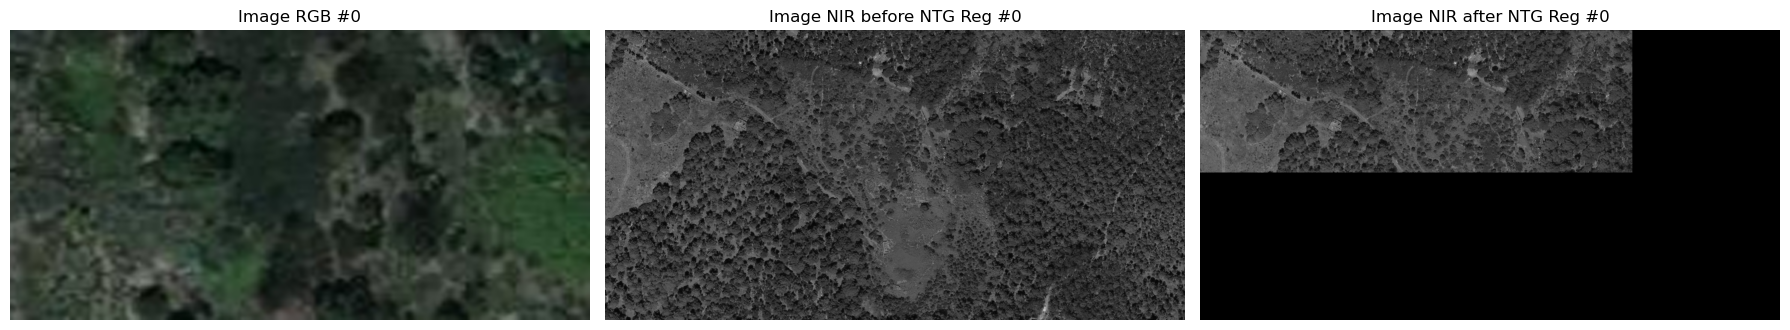

In [9]:
ntg_params_registration = []
history_ntg = []
img_NIR_warpedNTG = []

for n in range(len(img_RGB)):
    
    ## ------ NTG for Aerial Image Registration ------ ##
    ntg_registration_c2f, history_c2f, ntg_warped = aerial_image_reg_NTG_v2(img_RGB[n],img_NIR_translation[n],
                                                                            levels=4,scale_factor=2,

                                                                            scale_bounds=(0.005, 1.05),
                                                                            scale_samples=300,
                                                                            consistency_tol=0.02,

                                                                            local_population=10,
                                                                            local_generations=30,

                                                                            delta_translation=3.0,

                                                                            seed=42,
                                                                            
                                                                            global_population=20,
                                                                            global_generations=60,
                                                                            
                                                                            global_translation_ratio=0.90,
                                                                           
                                                                            global_scale_rel=0.30,
                                                                            global_shear_rel=0.05,

                                                                            min_overlap_global=0.25,
                                                                            
                                                                            translation_overlap_floor=0.05,
                                                                            translation_overlap_soft=0.85,
                                                                            translation_overlap_penalty=0.20,
                                                                            
                                                                            min_overlap_local=0.60
                                                                           )

    
    ## ------ Almacenamos los parametros, historial y warping de la toma ------ ##
    
    ntg_params_registration.append(ntg_registration_c2f)          # Parámetros Guardados
    history_ntg.append(history_c2f)                               # Historial de ajuste NTG
    img_NIR_warpedNTG.append(ntg_warped)                          # Warping de la imagen NIR

    ## ------ Visualización y comparativa de resultados ------ ##

    plt.figure(figsize=(18,10))

    plt.subplot(1,3,1)
    plt.title(f"Image RGB #{n}")
    plt.imshow(zoom_img_list[n])
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title(f"Image NIR before NTG Reg #{n}")
    plt.imshow(img_NIR[n],cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title(f"Image NIR after NTG Reg #{n}")
    plt.imshow(img_NIR_warpedNTG[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### FALSE-COLOR OVERLAY (ANTES DE NTG VS. DESPUÉS DE NTG)

In [10]:
def false_color_overlay(img_RGBgray,img_NIR,img_NIR_warped):

    def normalize_visual(img):
        
        img = img.astype(np.float32)

        min_val = np.min(img)
        max_val = np.max(img)

        return (img - min_val) / (max_val - min_val + 1e-8)

    img_RGB_ref = normalize_visual(img_RGBgray)
    img_NIR_bef_NTG = normalize_visual(img_NIR)
    img_NIR_aft_NTG = normalize_visual(img_NIR_warped)

    overlay_before = np.zeros((img_RGB_ref.shape[0],img_RGB_ref.shape[1],3),dtype=np.float32)

    overlay_after = np.zeros_like(overlay_before)

    # --- BEFORE --- #
    overlay_before[:, :, 0] = img_RGB_ref
    overlay_before[:, :, 1] = img_NIR_bef_NTG


    # --- AFTER --- #
    overlay_after[:, :, 0] = img_RGB_ref
    overlay_after[:, :, 1] = img_NIR_aft_NTG

    return overlay_before, overlay_after

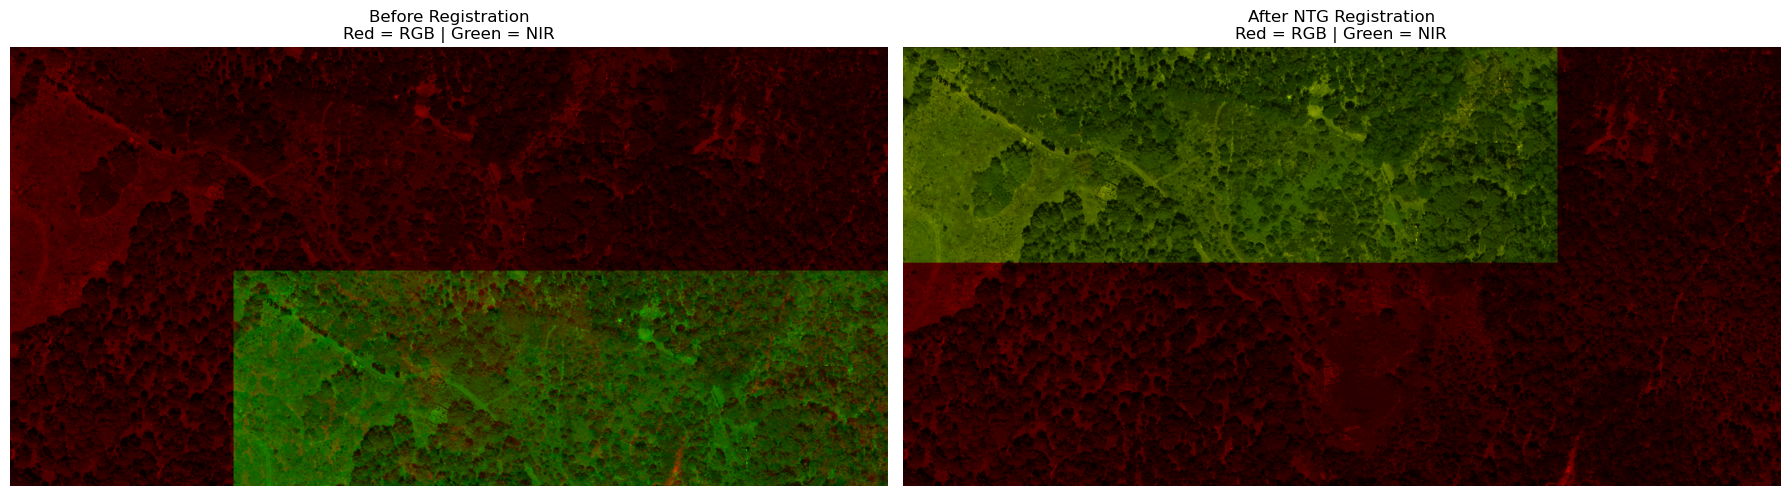

In [11]:
img_FC_before = []
img_FC_after = []

for n in range(len(img_RGB)):

    overlay_BEF_ntg, overlay_AFT_ntg = false_color_overlay(img_RGBgray[n],img_NIR_translation[n],img_NIR_warpedNTG[n])

    img_FC_before.append(overlay_BEF_ntg)
    img_FC_after.append(overlay_AFT_ntg)

    plt.figure(figsize=(18,10))

    plt.subplot(1,2,1)
    plt.title("Before Registration\n"
              "Red = RGB | Green = NIR")
    plt.imshow(img_FC_before[n])
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("After NTG Registration\n"
              "Red = RGB | Green = NIR")
    plt.imshow(img_FC_after[n])
    plt.axis('off')

    plt.tight_layout()
    plt.show()